In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


In [2]:

(ds_train, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.A03G69_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [3]:
print("Number of classes:", ds_info.features['label'].num_classes)
print("Class names:", ds_info.features['label'].names)


Number of classes: 5
Class names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


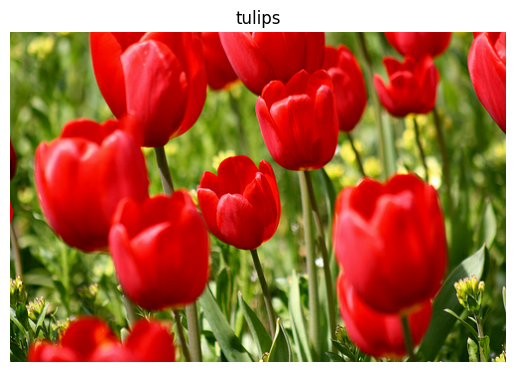

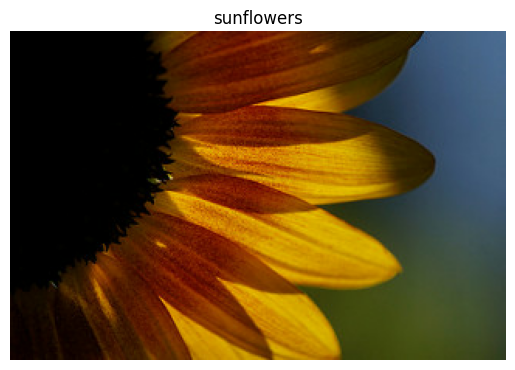

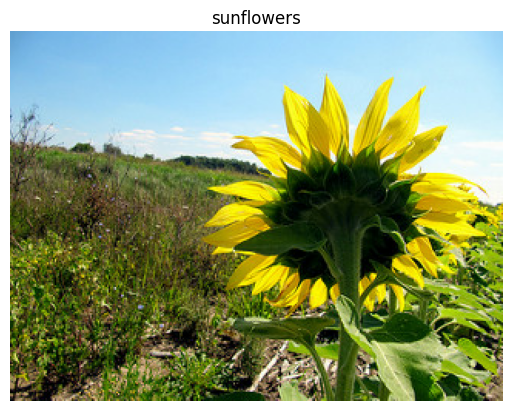

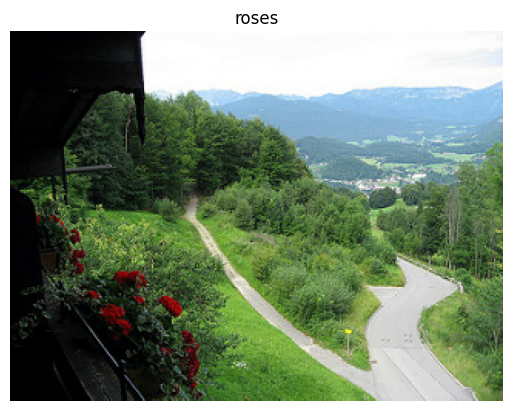

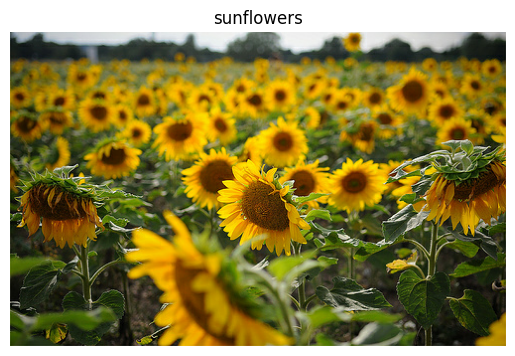

In [4]:
for image, label in ds_train.take(5):
    plt.figure()
    plt.imshow(image)
    plt.title(ds_info.features['label'].names[label])
    plt.axis('off')


In [5]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

ds_train = ds_train.map(preprocess).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(ds_info.features['label'].num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
model.fit(
    ds_train,
    validation_data= ds_test,
    epochs=10
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9784 - loss: 0.0779 - val_accuracy: 0.6757 - val_loss: 1.5010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9791 - loss: 0.0737 - val_accuracy: 0.6676 - val_loss: 1.5462
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9799 - loss: 0.0740 - val_accuracy: 0.6689 - val_loss: 1.5055
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.6880 - val_loss: 1.5895
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9813 - loss: 0.0611 - val_accuracy: 0.6771 - val_loss: 1.7208
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9957 - loss: 0.0247 - val_accuracy: 0.6717 - val_loss: 1.9277
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.6689 - val_loss: 2.0564
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9945 - loss: 0.0261 - val_accuracy: 0.6717 - 

In [10]:
loss, acc = model.evaluate(ds_test)
print(f"Test Accuracy: {acc*100:.2f}%")


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6593 - loss: 2.3629
Test Accuracy: 67.57%
